In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# ==================== Data Preprocessing ====================

# Technique: 3.2
data = pd.read_csv(r"./insurance.csv")
# data.info()
print("Shape: ", data.shape)

# Technique: 3.6
# ---------- Binary Encoding
data["sex"] = data["sex"].map({"male": 1, "female": 0})
data["smoker"] = data["smoker"].map({"yes": 1, "no": 0})
# data.info()

# ---------- One-Hot Encoding
data = pd.get_dummies(data, columns=["region"], drop_first=True)
bool_columns = data.select_dtypes(["boolean"]).columns
data[bool_columns] = data[bool_columns].astype("int64")
# data.info()

# 3.10
# ---------- Check for Null
data.isnull().sum()

# ---------- Save Cleaned Data
# data.to_csv(r"cleaned_data.csv", index=False)

Shape:  (1338, 7)


age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

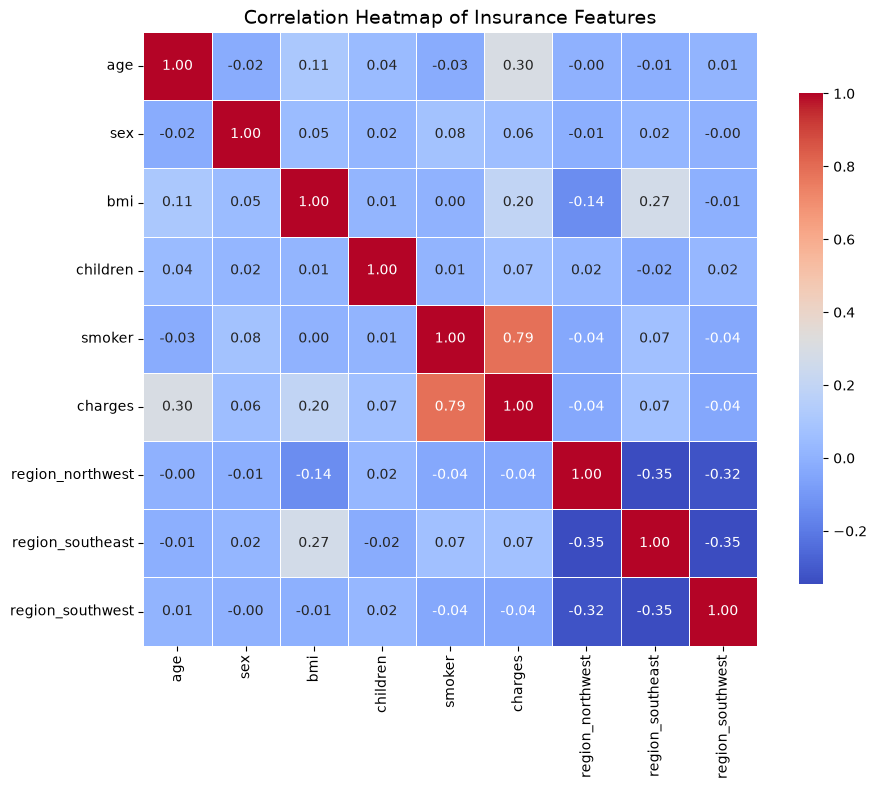

In [3]:
# ==================== Requirement 1 ====================

# ----------- Correlation Matrix
correlated_matrix = data.corr()
# print(correlated_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlated_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap of Insurance Features", fontsize=14)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
# plt.show()

C:\Users\dhyun\AppData\Local\Temp\ipykernel_15732\2764734856.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(["Non-Smoker", "Smoker"])


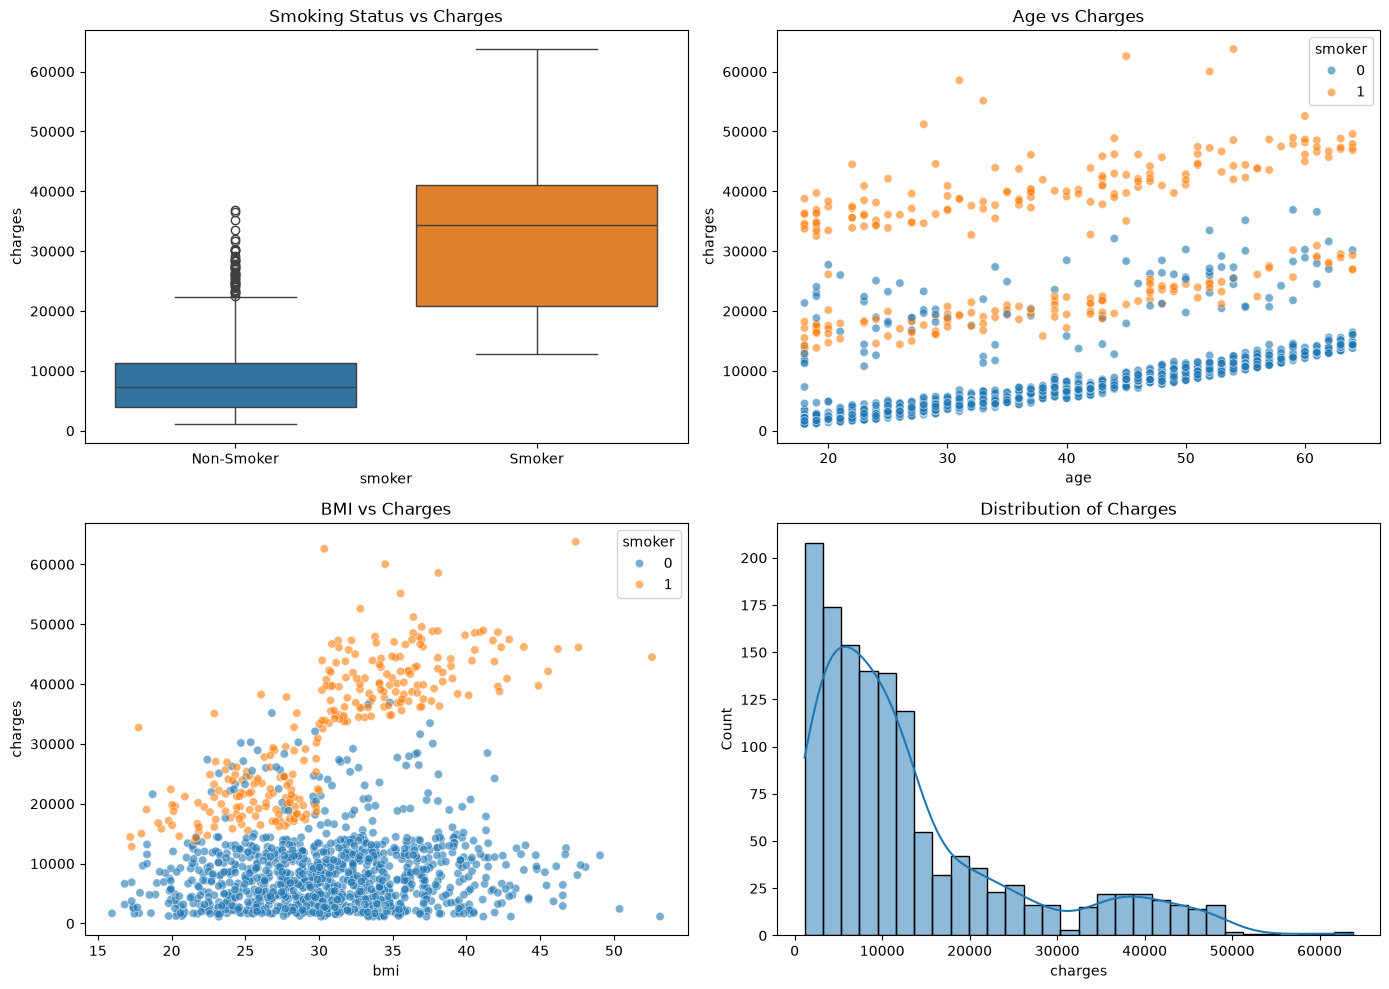

In [4]:
# ----------- Features and target relationship
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data, x="smoker", y="charges", hue="smoker", ax=axes[0, 0], legend=False)
axes[0, 0].set_title("Smoking Status vs Charges")
axes[0, 0].set_xticklabels(["Non-Smoker", "Smoker"])

sns.scatterplot(data, x="age", y="charges", hue="smoker", ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title("Age vs Charges")

sns.scatterplot(data, x="bmi", y="charges", hue="smoker", ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title("BMI vs Charges")

sns.histplot(data, x="charges", kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Charges")

plt.tight_layout()
plt.savefig("features_vs_charges.png", dpi=150)
# plt.show()

# Insight: The biggest factor is smoking status, followed by age and BMI.
# When smoking status is considered, the fatter and older individuals tend to have higher medical costs.

In [5]:
# ==================== Requirement 2 ====================
# ============ Multiple Linear Regression Model
feature_cols = [
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region_northwest",
    "region_southeast",
    "region_southwest",
]
X2 = data[feature_cols]
y2 = data["charges"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Fit traning data only
multi_linear_reg_model = LinearRegression()
multi_linear_reg_model.fit(X2_train, y2_train)

# Predict on the unseen test data
y_pred2 = multi_linear_reg_model.predict(X2_test)

In [6]:
# Evaluation
print("Test data score: ", multi_linear_reg_model.score(X2_test, y2_test))
print("Train data score: ", multi_linear_reg_model.score(X2_train, y2_train))

print("R2  :", round(r2_score(y2_test, y_pred2), 3))
print("MAE : $", round(mean_absolute_error(y2_test, y_pred2), 2))
print("MSE : $", round(mean_squared_error(y2_test, y_pred2), 2))
print("RMSE: $", round(mean_squared_error(y2_test, y_pred2) ** 0.5, 2))

Test data score:  0.7835929767120724
Train data score:  0.7417255854683333
R2  : 0.784
MAE : $ 4181.19
MSE : $ 33596915.85
RMSE: $ 5796.28


In [7]:
# ============ Ridge Regression (L2) Model
X4 = data[feature_cols]
y4 = data["charges"]

from sklearn.linear_model import Ridge

# Split
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42
)

# Tune alpha
# 3.17
def tune_ridge_alpha(alphas, X_train, y_train, X_test, y_test):
    scores = {}
    for alpha in alphas:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, y_train)
        r2 = ridge.score(X_test, y_test)
        scores[alpha] = r2
    return scores


# 3.18
alphas = [0.01, 0.1, 1, 10, 50, 100, 200]
scores = tune_ridge_alpha(alphas, X4_train, y4_train, X4_test, y4_test)
best_alpha = max(scores, key=scores.get)
print("Best alpha:", best_alpha)

Best alpha: 0.01


In [8]:
# Fit traning data only
ridge_reg_model = Ridge(
    alpha=0.01, max_iter=100, tol=0.1
)  # get tuned alpha from tune_ridge_alpha function
ridge_reg_model.fit(X4_train, y4_train)

# Predict on the unseen test data
y_pred4 = ridge_reg_model.predict(X4_test)

In [9]:
# Evaluation
print("Test data score: ", ridge_reg_model.score(X4_test, y4_test))
print("Train data score: ", ridge_reg_model.score(X4_train, y4_train))

print("R2  :", round(r2_score(y4_test, y_pred4), 3))
print("MAE : $", round(mean_absolute_error(y4_test, y_pred4), 2))
print("MSE : $", round(mean_squared_error(y4_test, y_pred4), 2))
print("RMSE: $", round(mean_squared_error(y4_test, y_pred4) ** 0.5, 2))

Test data score:  0.7835900459858819
Train data score:  0.7417255833627919
R2  : 0.784
MAE : $ 4181.32
MSE : $ 33597370.84
RMSE: $ 5796.32


In [10]:
# ============ Support Vector Regression (SVR) Model
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

X6 = data[feature_cols].to_numpy(float)
y6 = data["charges"].to_numpy(float)

# Scale the features
X6s = StandardScaler().fit_transform(X6)

# Split
X6_train, X6_test, y6_train, y6_test = train_test_split(
    X6s, y6, test_size=0.2, random_state=42
)

# Fit traning data only
svr_lin = SVR(kernel="linear", C=100, epsilon=1.5)
svr_poly = SVR(kernel="poly", degree=3, C=100, epsilon=1.5)
svr_rbf = SVR(kernel="rbf", gamma="scale", C=100, epsilon=1.5)

svr_lin.fit(X6_train, y6_train)
svr_poly.fit(X6_train, y6_train)
svr_rbf.fit(X6_train, y6_train)

# Predict on the unseen test data
y_pred6_lin = svr_lin.predict(X6_test)
y_pred6_poly = svr_poly.predict(X6_test)
y_pred6_rbf = svr_rbf.predict(X6_test)

In [11]:
# Evaluation
print("Test data score (svr_lin): ", svr_lin.score(X6_test, y6_test))
print("Train data score (svr_lin): ", svr_lin.score(X6_train, y6_train))

print("R2 (svr_lin)  :", round(r2_score(y6_test, y_pred6_lin), 3))
print("MAE (svr_lin) : $", round(mean_absolute_error(y6_test, y_pred6_lin), 2))
print("MSE (svr_lin) : $", round(mean_squared_error(y6_test, y_pred6_lin), 2))
print("RMSE (svr_lin): $", round(mean_squared_error(y6_test, y_pred6_lin) ** 0.5, 2))
# --------
print("Test data score (svr_poly): ", svr_poly.score(X6_test, y6_test))
print("Train data score (svr_poly): ", svr_poly.score(X6_train, y6_train))

print("R2 (svr_poly)  :", round(r2_score(y6_test, y_pred6_poly), 3))
print("MAE (svr_poly) : $", round(mean_absolute_error(y6_test, y_pred6_poly), 2))
print("MSE (svr_poly) : $", round(mean_squared_error(y6_test, y_pred6_poly), 2))
print("RMSE (svr_poly): $", round(mean_squared_error(y6_test, y_pred6_poly) ** 0.5, 2))
# --------
print("Test data score (svr_rbf): ", svr_rbf.score(X6_test, y6_test))
print("Train data score (svr_rbf): ", svr_rbf.score(X6_train, y6_train))

print("R2 (svr_rbf)  :", round(r2_score(y6_test, y_pred6_rbf), 3))
print("MAE (svr_rbf) : $", round(mean_absolute_error(y6_test, y_pred6_rbf), 2))
print("MSE (svr_rbf) : $", round(mean_squared_error(y6_test, y_pred6_rbf), 2))
print("RMSE (svr_rbf): $", round(mean_squared_error(y6_test, y_pred6_rbf) ** 0.5, 2))

Test data score (svr_lin):  0.6507150897605121
Train data score (svr_lin):  0.6073366423291641
R2 (svr_lin)  : 0.651
MAE (svr_lin) : $ 3558.8
MSE (svr_lin) : $ 54226039.24
RMSE (svr_lin): $ 7363.83
Test data score (svr_poly):  0.414228736437408
Train data score (svr_poly):  0.3581794467722482
R2 (svr_poly)  : 0.414
MAE (svr_poly) : $ 5625.9
MSE (svr_poly) : $ 90940245.61
RMSE (svr_poly): $ 9536.26
Test data score (svr_rbf):  0.24679752469515437
Train data score (svr_rbf):  0.21267226135830042
R2 (svr_rbf)  : 0.247
MAE (svr_rbf) : $ 5858.41
MSE (svr_rbf) : $ 116933728.85
RMSE (svr_rbf): $ 10813.59


In [12]:
# ==================== Requirement 3 ====================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import warnings

warnings.filterwarnings("ignore")

# 3.4 & 3.8
# Make the column for 'expensive' charge (0 = 'not expensive' charges not exceed median, 1 = 'expensive' charges exceed median)
median_charge = data["charges"].median()
print("median: ", median_charge)
data["expensive"] = (data["charges"] > median_charge).astype(int)
# print(data.head(3))

median:  9382.033


In [13]:
# Logistic Regression
# Load the data
# 3.11
X7 = data.drop(columns=["charges", "expensive"])
y7 = data[
    "expensive"
]  # target: 0 = charges not exceed median, 1 = charges exceed median

# 3.9
print(y7.value_counts())
data.head()

# Split into train and test sets
X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7, test_size=0.3, random_state=42
)

# Scale the features (fit on train only)
scaler = StandardScaler()
X7_train = scaler.fit_transform(X7_train)
X7_test = scaler.transform(X7_test)

expensive
1    669
0    669
Name: count, dtype: int64


In [14]:
# Train the model (training data only)
classification_model = LogisticRegression(
    solver="lbfgs", max_iter=1000, random_state=8888
)
classification_model.fit(X7_train, y7_train)

# Step 6: Predict on the test set
y_pred7 = classification_model.predict(X7_test)

print(classification_report(y7_test, y_pred7))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       207
           1       0.90      0.90      0.90       195

    accuracy                           0.90       402
   macro avg       0.90      0.90      0.90       402
weighted avg       0.90      0.90      0.90       402



In [15]:
# Evaluate with a confusion matrix
cm = confusion_matrix(y7_test, y_pred7)
print(cm)

# Rows = actual charge, columns = predicted charge
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (not expensive correctly passed):   {tn}")
print(f"False Positives (not expensive wrongly flagged):    {fp}")
print(f"False Negatives (expensive missed):             {fn}")
print(f"True Positives  (expensive correctly caught):   {tp}")

[[187  20]
 [ 19 176]]
True Negatives  (not expensive correctly passed):   187
False Positives (not expensive wrongly flagged):    20
False Negatives (expensive missed):             19
True Positives  (expensive correctly caught):   176


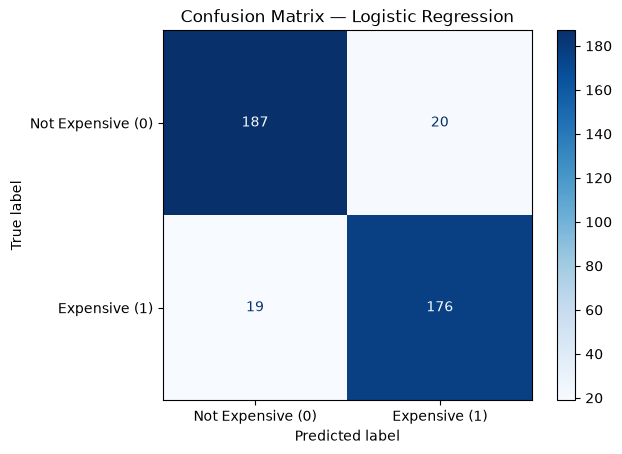

In [16]:
# Plot the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Not Expensive (0)", "Expensive (1)"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

In [ ]:
# Extra
# 3.14 & 3.16
data.groupby('smoker')['charges'].mean()
data.groupby('smoker')['charges'].agg(['mean', 'median', 'max'])

,mean,median,max
smoker,,,
0,8434.268298,7345.40530,36910.60803
1,32050.231832,34456.34845,63770.42801
